# Projet de Fin d'Année (PFA)
## Comparaison de 4 Architectures pour la Segmentation d'Images Médicales
### Dataset : BraTS2020 — Tumeurs Cérébrales

**Spécialité :** IA & Data (4IIR)  
**Dataset :** BraTS2020 (Brain Tumor Segmentation 2020)

---

## Architectures comparées :
| # | Modèle | Type | Particularité |
|---|--------|------|---------------|
| 1 | **U-Net** | Encoder-Decoder | Skip connections, conçu pour le médical |
| 2 | **ResNet-50 + Decoder** | Backbone ResiduelEncod. | Residual learning, deep features |
| 3 | **VGG16 + Decoder** | Backbone Encodeur | Features riches, classique |
| 4 | **SegNet** | Encoder-Decoder | Max-pooling indices, efficace mémoire |

---


# 1. Installation et Importations

In [1]:
# Installations nécessaires (exécuter si sur Colab/Kaggle)
# !pip install nibabel scikit-image tqdm -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
import os, glob, cv2, time
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

import nibabel as nib
from skimage.transform import resize

np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU disponible : {tf.config.list_physical_devices('GPU')}")
print(" Toutes les bibliothèques importées avec succès")

TensorFlow version : 2.21.0
GPU disponible : []
 Toutes les bibliothèques importées avec succès


# 2. Configuration Globale

In [ ]:
# ============================================================
#  PARAMÈTRES GLOBAUX — à adapter selon votre environnement
# ============================================================
DATA_PATH = r"PATH" #Dataset link : https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation

IMG_SIZE       = 128     # Taille des images (128x128)
NUM_CLASSES    = 4       # 0=fond, 1=nécrose, 2=œdème, 3=tumeur active
VOLUME_START   = 22      # Coupe de départ (éviter les coupes vides)
VOLUME_SLICES  = 100     # Coupes par patient
MAX_PATIENTS   = 50      # Patients à utiliser (None = tous)
EPOCHS         = 10     # Epochs d'entraînement
BATCH_SIZE     = 16
LEARNING_RATE  = 1e-3

SEGMENT_CLASSES = {0: 'Fond (BG)', 1: 'Nécrose (NCR)', 2: 'Œdème (ED)', 3: 'Tumeur Active (ET)'}
CLASS_COLORS    = ['#1a1a2e', '#4361ee', '#2dc653', '#ef233c']

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('logs', exist_ok=True)

print("Configuration :")
print(f"  IMG_SIZE      : {IMG_SIZE}x{IMG_SIZE}")
print(f"  NUM_CLASSES   : {NUM_CLASSES}")
print(f"  MAX_PATIENTS  : {MAX_PATIENTS}")
print(f"  EPOCHS        : {EPOCHS}")
print(f"  BATCH_SIZE    : {BATCH_SIZE}")

Configuration :
  IMG_SIZE      : 128x128
  NUM_CLASSES   : 4
  MAX_PATIENTS  : 50
  EPOCHS        : 10
  BATCH_SIZE    : 16


# 3. Métriques Custom (Mean IoU corrigé)

**Pourquoi recoder les métriques ?**  
`tf.keras.metrics.MeanIoU` souffre d'un bug bien documenté : son état interne (matrice de confusion) s'accumule sans reset entre les epochs, ce qui donne une valeur figée.  
La solution est d'implémenter le Mean IoU comme une **fonction** (non-stateful), calculée pixel par pixel.

In [4]:
# ============================================================
#  MÉTRIQUES CUSTOM — corrigées et stables
# ============================================================

smooth = 1e-6

def dice_coef(y_true, y_pred):
    """Dice coefficient global."""
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coef_loss(y_true, y_pred):
    """Loss combinée : CrossEntropy + Dice (réduit le déséquilibre de classes)."""
    ce_loss  = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    dice_loss = 1 - dice_coef(y_true, y_pred)
    return ce_loss + dice_loss

def mean_iou_fixed(y_true, y_pred):
    """
    Mean IoU CORRIGÉ — calcul fonctionnel sans state.
    Évite le bug de tf.keras.metrics.MeanIoU qui reste fixe.
    """
    y_true_int = tf.cast(tf.argmax(y_true, axis=-1), tf.int32)
    y_pred_int = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
    iou_list = []
    for c in range(NUM_CLASSES):
        true_c = tf.cast(tf.equal(y_true_int, c), tf.float32)
        pred_c = tf.cast(tf.equal(y_pred_int, c), tf.float32)
        intersection = K.sum(true_c * pred_c)
        union        = K.sum(true_c) + K.sum(pred_c) - intersection
        iou = (intersection + smooth) / (union + smooth)
        iou_list.append(iou)
    return tf.reduce_mean(iou_list)

def dice_class(class_idx):
    """Dice pour une classe spécifique."""
    def dice(y_true, y_pred):
        y_true_c = y_true[..., class_idx]
        y_pred_c = y_pred[..., class_idx]
        intersection = K.sum(y_true_c * y_pred_c)
        return (2. * intersection + smooth) / (K.sum(y_true_c) + K.sum(y_pred_c) + smooth)
    dice.__name__ = f'dice_class_{class_idx}'
    return dice

def precision(y_true, y_pred):
    true_pos = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    pred_pos = K.sum(K.round(K.clip(y_pred, 0, 1)))
    return true_pos / (pred_pos + smooth)

def sensitivity(y_true, y_pred):  # Recall
    true_pos = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    pos      = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_pos / (pos + smooth)

def specificity(y_true, y_pred):
    true_neg = K.sum(K.round(K.clip((1-y_true)*(1-y_pred), 0, 1)))
    neg      = K.sum(K.round(K.clip(1-y_true, 0, 1)))
    return true_neg / (neg + smooth)

# Dice par classe nommées
dice_necrotic  = dice_class(1); dice_necrotic.__name__  = 'dice_necrotic'
dice_edema     = dice_class(2); dice_edema.__name__     = 'dice_edema'
dice_enhancing = dice_class(3); dice_enhancing.__name__ = 'dice_enhancing'

METRICS = [
    'accuracy',
    mean_iou_fixed,
    dice_coef,
    precision,
    sensitivity,
    specificity,
    dice_necrotic,
    dice_edema,
    dice_enhancing
]

print(" Métriques custom chargées :")
for m in METRICS:
    name = m if isinstance(m, str) else m.__name__
    print(f"   - {name}")

 Métriques custom chargées :
   - accuracy
   - mean_iou_fixed
   - dice_coef
   - precision
   - sensitivity
   - specificity
   - dice_necrotic
   - dice_edema
   - dice_enhancing


# 4. Chargement et Prétraitement des Données

In [5]:
def normalize_volume(volume):
    """Normalisation min-max entre 0 et 1."""
    vmin, vmax = np.min(volume), np.max(volume)
    return (volume - vmin) / (vmax - vmin + 1e-8)

def convert_mask(seg):
    """Convertit les classes BraTS (0,1,2,4) → (0,1,2,3)."""
    s = seg.copy()
    s[seg == 4] = 3
    return s

def load_patient_data(patient_path, img_size=IMG_SIZE,
                      start=VOLUME_START, n_slices=VOLUME_SLICES):
    """
    Charge T1ce, T2, FLAIR + masque pour un patient.
    Retourne X (n_slices, H, W, 3) et y (n_slices, H, W, 4).
    """
    pid = os.path.basename(patient_path)
    
    t1ce  = normalize_volume(nib.load(f"{patient_path}/{pid}_t1ce.nii").get_fdata())
    t2    = normalize_volume(nib.load(f"{patient_path}/{pid}_t2.nii").get_fdata())
    flair = normalize_volume(nib.load(f"{patient_path}/{pid}_flair.nii").get_fdata())
    seg   = convert_mask(nib.load(f"{patient_path}/{pid}_seg.nii").get_fdata())
    
    X_slices, y_slices = [], []
    for sl in range(start, start + n_slices):
        # Redimensionner chaque modalité
        ch = np.stack([
            resize(t1ce[..., sl],  (img_size, img_size), anti_aliasing=True),
            resize(t2[..., sl],    (img_size, img_size), anti_aliasing=True),
            resize(flair[..., sl], (img_size, img_size), anti_aliasing=True)
        ], axis=-1)
        
        mask = resize(seg[..., sl], (img_size, img_size),
                      order=0, preserve_range=True, anti_aliasing=False).astype(int)
        mask_oh = tf.keras.utils.to_categorical(mask, num_classes=NUM_CLASSES)
        
        X_slices.append(ch)
        y_slices.append(mask_oh)
    
    return np.array(X_slices, dtype=np.float32), np.array(y_slices, dtype=np.float32)


def prepare_dataset(data_path, max_patients=MAX_PATIENTS):
    """Charge tous les patients et retourne X, y complets."""
    patient_ids = sorted([f for f in os.listdir(data_path) if f.startswith('BraTS20')])
    if max_patients:
        patient_ids = patient_ids[:max_patients]
    
    print(f"Chargement de {len(patient_ids)} patients...")
    X_all, y_all = [], []
    
    for pid in tqdm(patient_ids):
        path = os.path.join(data_path, pid)
        try:
            X_p, y_p = load_patient_data(path)
            X_all.append(X_p)
            y_all.append(y_p)
        except Exception as e:
            print(f"    Erreur sur {pid}: {e}")
    
    X = np.concatenate(X_all, axis=0)
    y = np.concatenate(y_all, axis=0)
    print(f"\nDataset chargé : X={X.shape}, y={y.shape}")
    print(f"Mémoire estimée : {X.nbytes/1e9:.2f} Go")
    return X, y


# Chargement
X, y = prepare_dataset(DATA_PATH)

# Split train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val,   X_test,  y_val,  y_test  = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"\nSplit dataset :")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")

Chargement de 50 patients...


100%|██████████| 50/50 [00:35<00:00,  1.40it/s]



Dataset chargé : X=(5000, 128, 128, 3), y=(5000, 128, 128, 4)
Mémoire estimée : 0.98 Go

Split dataset :
  Train : (3500, 128, 128, 3)
  Val   : (750, 128, 128, 3)
  Test  : (750, 128, 128, 3)


## 4.1 Visualisation des Données

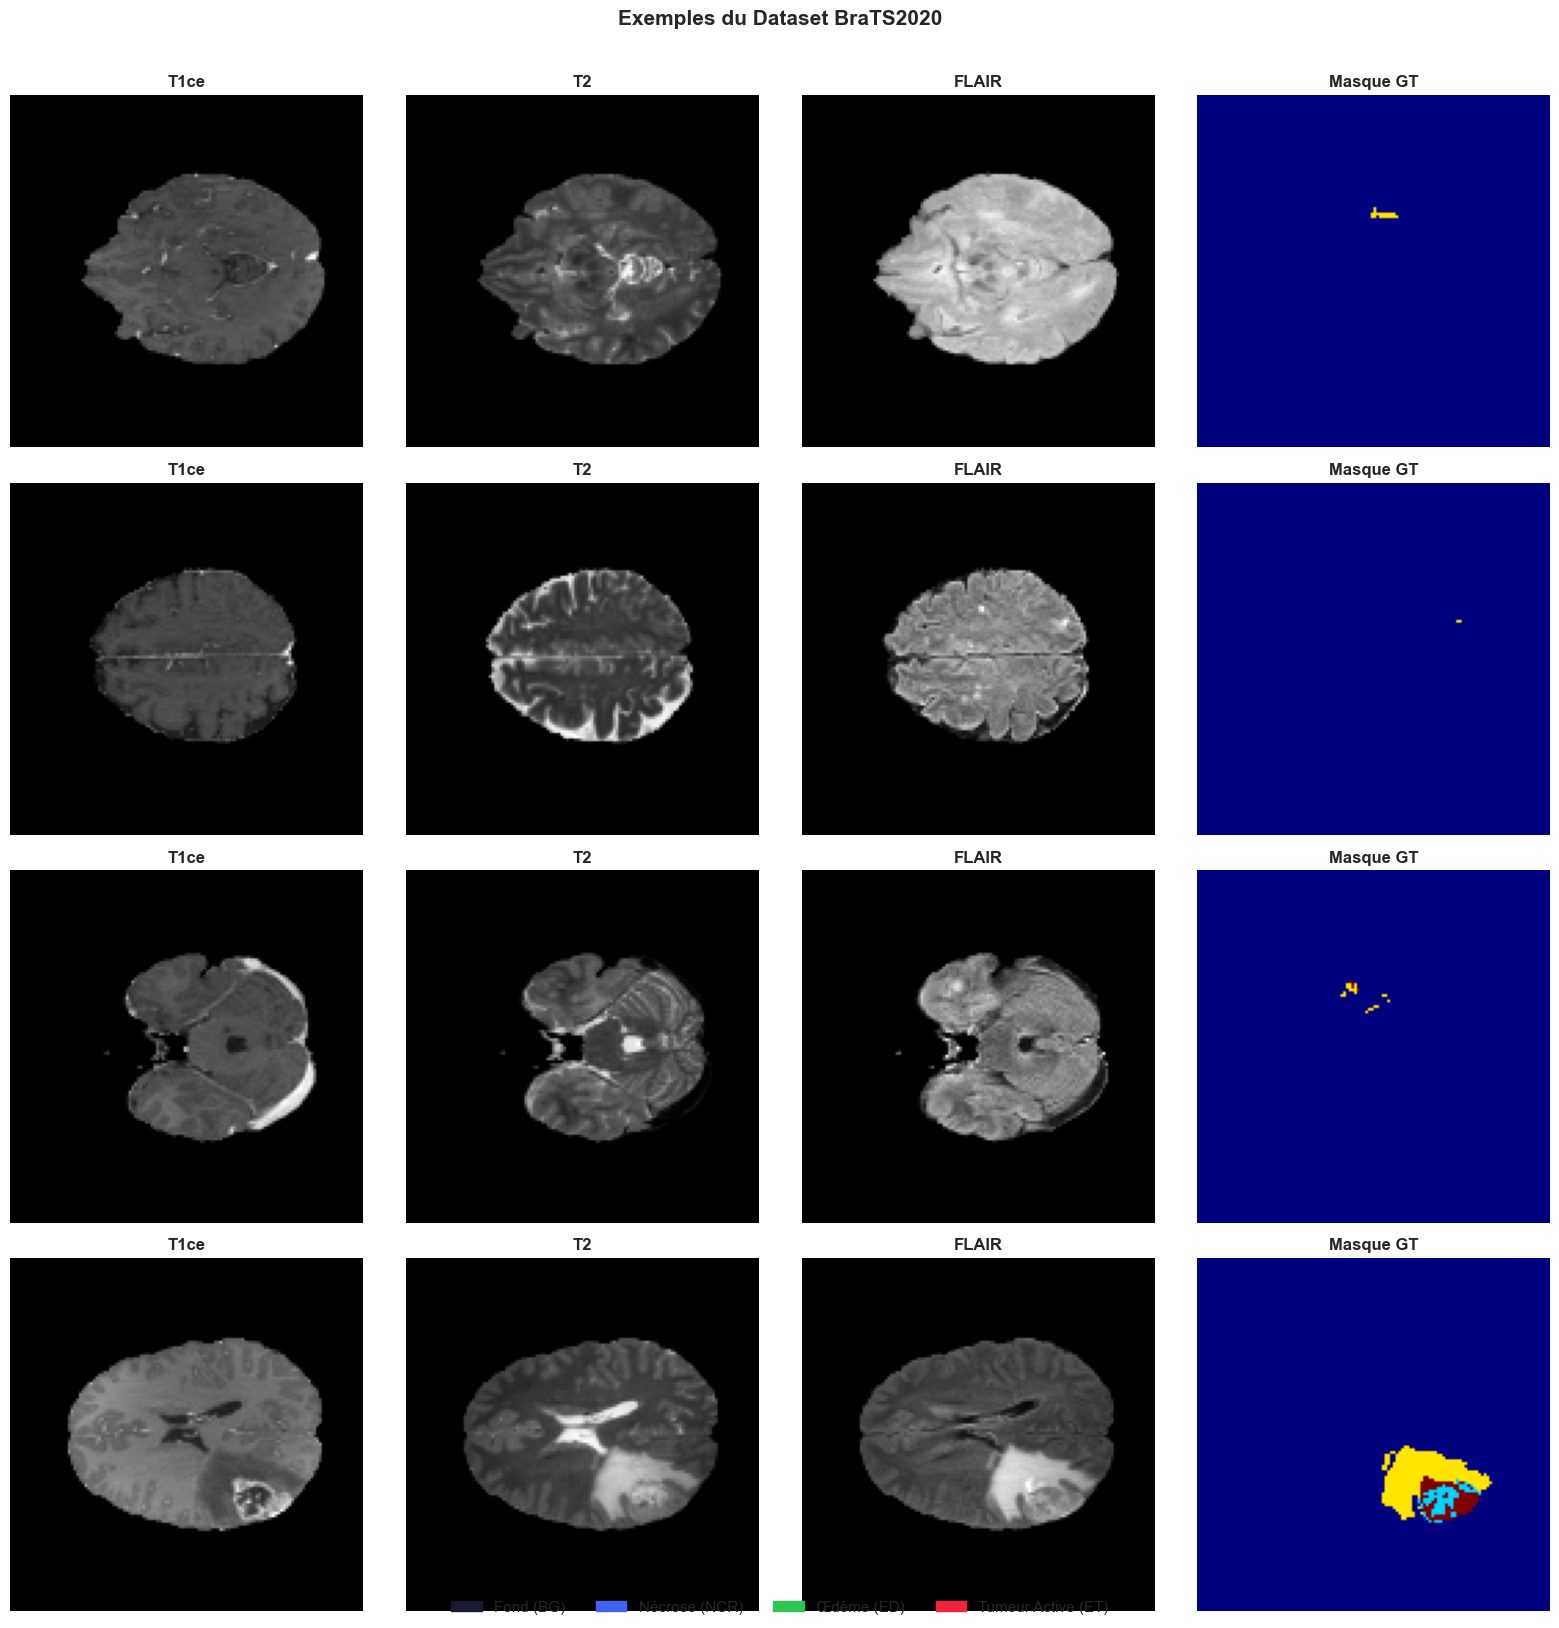

In [6]:
def visualize_sample(X, y, n=4):
    """Visualise n exemples : image + masque vérité terrain."""
    indices = np.random.choice(len(X), n, replace=False)
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    
    for row, idx in enumerate(indices):
        for ch, title in enumerate(['T1ce', 'T2', 'FLAIR']):
            axes[row, ch].imshow(X[idx, :, :, ch], cmap='gray')
            axes[row, ch].set_title(title, fontweight='bold')
            axes[row, ch].axis('off')
        
        mask = np.argmax(y[idx], axis=-1)
        im = axes[row, 3].imshow(mask, cmap='jet', vmin=0, vmax=3)
        axes[row, 3].set_title('Masque GT', fontweight='bold')
        axes[row, 3].axis('off')
    
    legend_patches = [mpatches.Patch(color=CLASS_COLORS[c], label=SEGMENT_CLASSES[c])
                      for c in range(NUM_CLASSES)]
    fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=11)
    plt.suptitle('Exemples du Dataset BraTS2020', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

visualize_sample(X_train, y_train)

# 5. Architectures des 4 Modèles

---

## 5.1 Modèle 1 — U-Net (Architecture originale)

In [7]:
def conv_block(x, filters, kernel_size=3, activation='relu', batch_norm=True):
    """Bloc convolutionnel double avec BatchNorm optionnel."""
    for _ in range(2):
        x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
        if batch_norm:
            x = layers.BatchNormalization()(x)
        x = layers.Activation(activation)(x)
    return x

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    U-Net original avec skip connections.
    Architecture symétrique encoder-decoder.
    Référence : Ronneberger et al., 2015
    """
    inputs = layers.Input(input_shape)
    
    # ── Encoder ──
    c1 = conv_block(inputs, 64);   p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 128);      p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 256);      p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 512);      p4 = layers.MaxPooling2D()(c4)
    
    # ── Bottleneck ──
    bn = conv_block(p4, 1024)
    bn = layers.Dropout(0.3)(bn)
    
    # ── Decoder avec Skip Connections ──
    u6 = layers.Conv2DTranspose(512, 2, strides=2, padding='same')(bn)
    u6 = layers.concatenate([u6, c4])
    c6 = conv_block(u6, 512)
    
    u7 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = conv_block(u7, 256)
    
    u8 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = conv_block(u8, 128)
    
    u9 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = conv_block(u9, 64)
    
    # Sortie
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(c9)
    
    return models.Model(inputs, outputs, name='UNet')

unet = build_unet()
print(f"U-Net — Paramètres : {unet.count_params():,}")
unet.summary(line_length=80)

U-Net — Paramètres : 31,055,492


Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, 128, 128,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, 128, 128,  │       1,792 │ input_layer[0][0]  │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, 128, 128,  │         256 │ conv2d[0][0]       │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation            │ (None, 128, 128,  │           0 │ batch_normalizati… │
│ (Activation)          │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, 128, 128,  │      36,928 │ activation[0][0]   │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, 128, 128,  │         256 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_1          │ (None, 128, 128,  │           0 │ batch_normalizati… │
│ (Activation)          │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d         │ (None, 64, 64,    │           0 │ activation_1[0][0] │
│ (MaxPooling2D)        │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, 64, 64,    │      73,856 │ max_pooling2d[0][… │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, 64, 64,    │         512 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_2          │ (None, 64, 64,    │           0 │ batch_normalizati… │
│ (Activation)          │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_3 (Conv2D)     │ (None, 64, 64,    │     147,584 │ activation_2[0][0] │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_3 │ (None, 64, 64,    │         512 │ conv2d_3[0][0]     │
│ (BatchNormalization)  │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_3          │ (None, 64, 64,    │           0 │ batch_normalizati… │
│ (Activation)          │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_1       │ (None, 32, 32,    │           0 │ activation_3[0][0] │
│ (MaxPooling2D)        │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_4 (Conv2D)     │ (None, 32, 32,    │     295,168 │ max_pooling2d_1[0… │
│                       │ 256) 

 Total params: 31,055,492 (118.47 MB)

 Trainable params: 31,043,716 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

## 5.2 Modèle 2 — ResNet-50 + Decoder (Transfer Learning)

In [8]:
def build_resnet_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    ResNet-50 comme encodeur (ImageNet) + decoder U-Net.
    Les residual blocks apportent un gradient plus stable en profondeur.
    """
    base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Extraire les feature maps à différentes résolutions
    s1 = base.get_layer('conv1_relu').output          # 64x64x64
    s2 = base.get_layer('conv2_block3_out').output    # 32x32x256
    s3 = base.get_layer('conv3_block4_out').output    # 16x16x512
    s4 = base.get_layer('conv4_block6_out').output    # 8x8x1024
    bridge = base.get_layer('conv5_block3_out').output # 4x4x2048
    
    # Decoder
    def decoder_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
        x = layers.concatenate([x, skip])
        x = conv_block(x, filters)
        return x
    
    d1 = decoder_block(bridge, s4, 512)
    d2 = decoder_block(d1,     s3, 256)
    d3 = decoder_block(d2,     s2, 128)
    d4 = decoder_block(d3,     s1,  64)
    
    # Upsampling final pour retrouver la taille d'entrée
    x = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(d4)
    x = conv_block(x, 32)
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(x)
    
    return models.Model(base.input, outputs, name='ResNet50_UNet')

resnet_model = build_resnet_unet()
print(f"ResNet-50+Decoder — Paramètres : {resnet_model.count_params():,}")

ResNet-50+Decoder — Paramètres : 41,004,708


## 5.3 Modèle 3 — VGG16 + Decoder (Transfer Learning)

In [9]:
def build_vgg16_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    VGG16 comme encodeur (ImageNet) + decoder léger.
    Architecture simple avec features très riches.
    """
    base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Skip connections depuis les blocs de VGG16
    s1 = base.get_layer('block1_conv2').output  # 128x128x64
    s2 = base.get_layer('block2_conv2').output  # 64x64x128
    s3 = base.get_layer('block3_conv3').output  # 32x32x256
    s4 = base.get_layer('block4_conv3').output  # 16x16x512
    bridge = base.get_layer('block5_conv3').output # 8x8x512
    
    # Decoder
    def decoder_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
        x = layers.concatenate([x, skip])
        x = conv_block(x, filters)
        return x
    
    d1 = decoder_block(bridge, s4, 512)
    d2 = decoder_block(d1,     s3, 256)
    d3 = decoder_block(d2,     s2, 128)
    d4 = decoder_block(d3,     s1,  64)
    
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(d4)
    
    return models.Model(base.input, outputs, name='VGG16_UNet')

vgg_model = build_vgg16_unet()
print(f"VGG16+Decoder — Paramètres : {vgg_model.count_params():,}")

VGG16+Decoder — Paramètres : 25,862,532


## 5.4 Modèle 4 — SegNet

In [10]:
def build_segnet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    SegNet : Encoder-Decoder symétrique.
    Utilise les indices de max-pooling pour l'upsampling (économe en mémoire).
    Référence : Badrinarayanan et al., 2017
    """
    inputs = layers.Input(input_shape)
    
    # ── Encoder ──
    # Bloc 1
    x = conv_block(inputs, 64);   p1 = layers.MaxPooling2D(pool_size=2, strides=2)(x)
    # Bloc 2
    x = conv_block(p1, 128);      p2 = layers.MaxPooling2D(pool_size=2, strides=2)(x)
    # Bloc 3
    x = conv_block(p2, 256)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    p3 = layers.MaxPooling2D(pool_size=2, strides=2)(x)
    # Bloc 4
    x = conv_block(p3, 512)
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    p4 = layers.MaxPooling2D(pool_size=2, strides=2)(x)
    # Bloc 5
    x = conv_block(p4, 512)
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    p5 = layers.MaxPooling2D(pool_size=2, strides=2)(x)
    
    # ── Decoder — upsampling progressif ──
    x = layers.UpSampling2D(size=2)(p5)
    x = conv_block(x, 512)
    
    x = layers.UpSampling2D(size=2)(x)
    x = conv_block(x, 512)
    
    x = layers.UpSampling2D(size=2)(x)
    x = conv_block(x, 256)
    
    x = layers.UpSampling2D(size=2)(x)
    x = conv_block(x, 128)
    
    x = layers.UpSampling2D(size=2)(x)
    x = conv_block(x, 64)
    
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(x)
    
    return models.Model(inputs, outputs, name='SegNet')

segnet = build_segnet()
print(f"SegNet — Paramètres : {segnet.count_params():,}")

SegNet — Paramètres : 26,501,060


## 5.5 Résumé des Architectures

In [11]:
models_dict = {
    'U-Net':         unet,
    'ResNet50-UNet': resnet_model,
    'VGG16-UNet':    vgg_model,
    'SegNet':        segnet
}

print("╔══════════════════╦═══════════════╦═══════════════════════════════════════╗")
print("║ Modèle           ║ Paramètres    ║ Caractéristique principale            ║")
print("╠══════════════════╬═══════════════╬═══════════════════════════════════════╣")
descs = [
    'Skip connections, conçu pour le médical',
    'Residual blocks, ImageNet pretrained',
    'Deep features classiques, pretrained',
    'Upsampling simple, économe en mémoire'
]
for (name, m), desc in zip(models_dict.items(), descs):
    params = f"{m.count_params():,}"
    print(f"║ {name:<16} ║ {params:>13} ║ {desc:<37} ║")
print("╚══════════════════╩═══════════════╩═══════════════════════════════════════╝")

╔══════════════════╦═══════════════╦═══════════════════════════════════════╗
║ Modèle           ║ Paramètres    ║ Caractéristique principale            ║
╠══════════════════╬═══════════════╬═══════════════════════════════════════╣
║ U-Net            ║    31,055,492 ║ Skip connections, conçu pour le médical ║
║ ResNet50-UNet    ║    41,004,708 ║ Residual blocks, ImageNet pretrained  ║
║ VGG16-UNet       ║    25,862,532 ║ Deep features classiques, pretrained  ║
║ SegNet           ║    26,501,060 ║ Upsampling simple, économe en mémoire ║
╚══════════════════╩═══════════════╩═══════════════════════════════════════╝


# 6. Entraînement des 4 Modèles

In [12]:
def get_callbacks(model_name):
    """Callbacks standards pour chaque modèle."""
    return [
        ModelCheckpoint(
            f'checkpoints/best_{model_name}.h5',
            monitor='val_dice_coef', mode='max',
            save_best_only=True, verbose=0
        ),
        EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=4, min_lr=1e-7, verbose=1
        ),
        CSVLogger(f'logs/history_{model_name}.csv')
    ]


def train_model(model, model_name, X_train, y_train, X_val, y_val,
                epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE):
    """
    Compile et entraîne un modèle.
    Retourne l'historique et le temps d'entraînement.
    """
    print(f"\n{'='*60}")
    print(f"  Entraînement : {model_name}")
    print(f"{'='*60}")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=dice_coef_loss,
        metrics=METRICS
    )
    
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=get_callbacks(model_name),
        verbose=1
    )
    elapsed = time.time() - start_time
    
    print(f"\n {model_name} entraîné en {elapsed/60:.1f} minutes")
    return history, elapsed


# Initialisation des dictionnaires de résultats
all_histories = {}
all_times     = {}


In [13]:
# ── Entraînement : U-Net ──
#hist_unet, t_unet = train_model(unet, 'U-Net', X_train, y_train, X_val, y_val)
#all_histories['U-Net'] = hist_unet
#all_times['U-Net']     = t_unet


In [14]:
# ── Entraînement : ResNet50-UNet ──
#hist_resnet, t_resnet = train_model(resnet_model, 'ResNet50-UNet', X_train, y_train, X_val, y_val)
#all_histories['ResNet50-UNet'] = hist_resnet
#all_times['ResNet50-UNet']     = t_resnet


In [15]:
# ── Entraînement : VGG16-UNet ──
#hist_vgg, t_vgg = train_model(vgg_model, 'VGG16-UNet', X_train, y_train, X_val, y_val)
#all_histories['VGG16-UNet'] = hist_vgg
#all_times['VGG16-UNet']     = t_vgg


In [16]:
# ── Entraînement : SegNet ──
#hist_segnet, t_segnet = train_model(segnet, 'SegNet', X_train, y_train, X_val, y_val)
#all_histories['SegNet'] = hist_segnet
#all_times['SegNet']     = t_segnet

#print("\n" + "="*60)
#print(" Entraînement de tous les modèles terminé !")
#print("="*60)


In [17]:
# ── Chargement des modèles sauvegardés ──
# Charger les meilleurs poids de chaque modèle après entraînement

from tensorflow.keras.models import load_model

custom_objects = {
    'dice_coef_loss':  dice_coef_loss,
    'dice_coef':       dice_coef,
    'mean_iou_fixed':  mean_iou_fixed,
    'precision':       precision,
    'sensitivity':     sensitivity,
    'specificity':     specificity,
    'dice_necrotic':   dice_necrotic,
    'dice_edema':      dice_edema,
    'dice_enhancing':  dice_enhancing,
}

unet         = load_model('checkpoints/best_U-Net.h5',         custom_objects=custom_objects)
resnet_model = load_model('checkpoints/best_ResNet50-UNet.h5', custom_objects=custom_objects)
vgg_model    = load_model('checkpoints/best_VGG16-UNet.h5',    custom_objects=custom_objects)
segnet       = load_model('checkpoints/best_SegNet.h5',        custom_objects=custom_objects)

models_dict = {
    'U-Net':         unet,
    'ResNet50-UNet': resnet_model,
    'VGG16-UNet':    vgg_model,
    'SegNet':        segnet,
}

print(" Modèles chargés avec succès :")
for name in models_dict:
    print(f"   ✔ {name}")


 Modèles chargés avec succès :
   ✔ U-Net
   ✔ ResNet50-UNet
   ✔ VGG16-UNet
   ✔ SegNet


# 7. Visualisation des Courbes d'Entraînement

  ✔ Historique chargé : logs/history_U-Net.csv
  ✔ Historique chargé : logs/history_ResNet50-UNet.csv
  ✔ Historique chargé : logs/history_VGG16-UNet.csv
  ✔ Historique chargé : logs/history_SegNet.csv


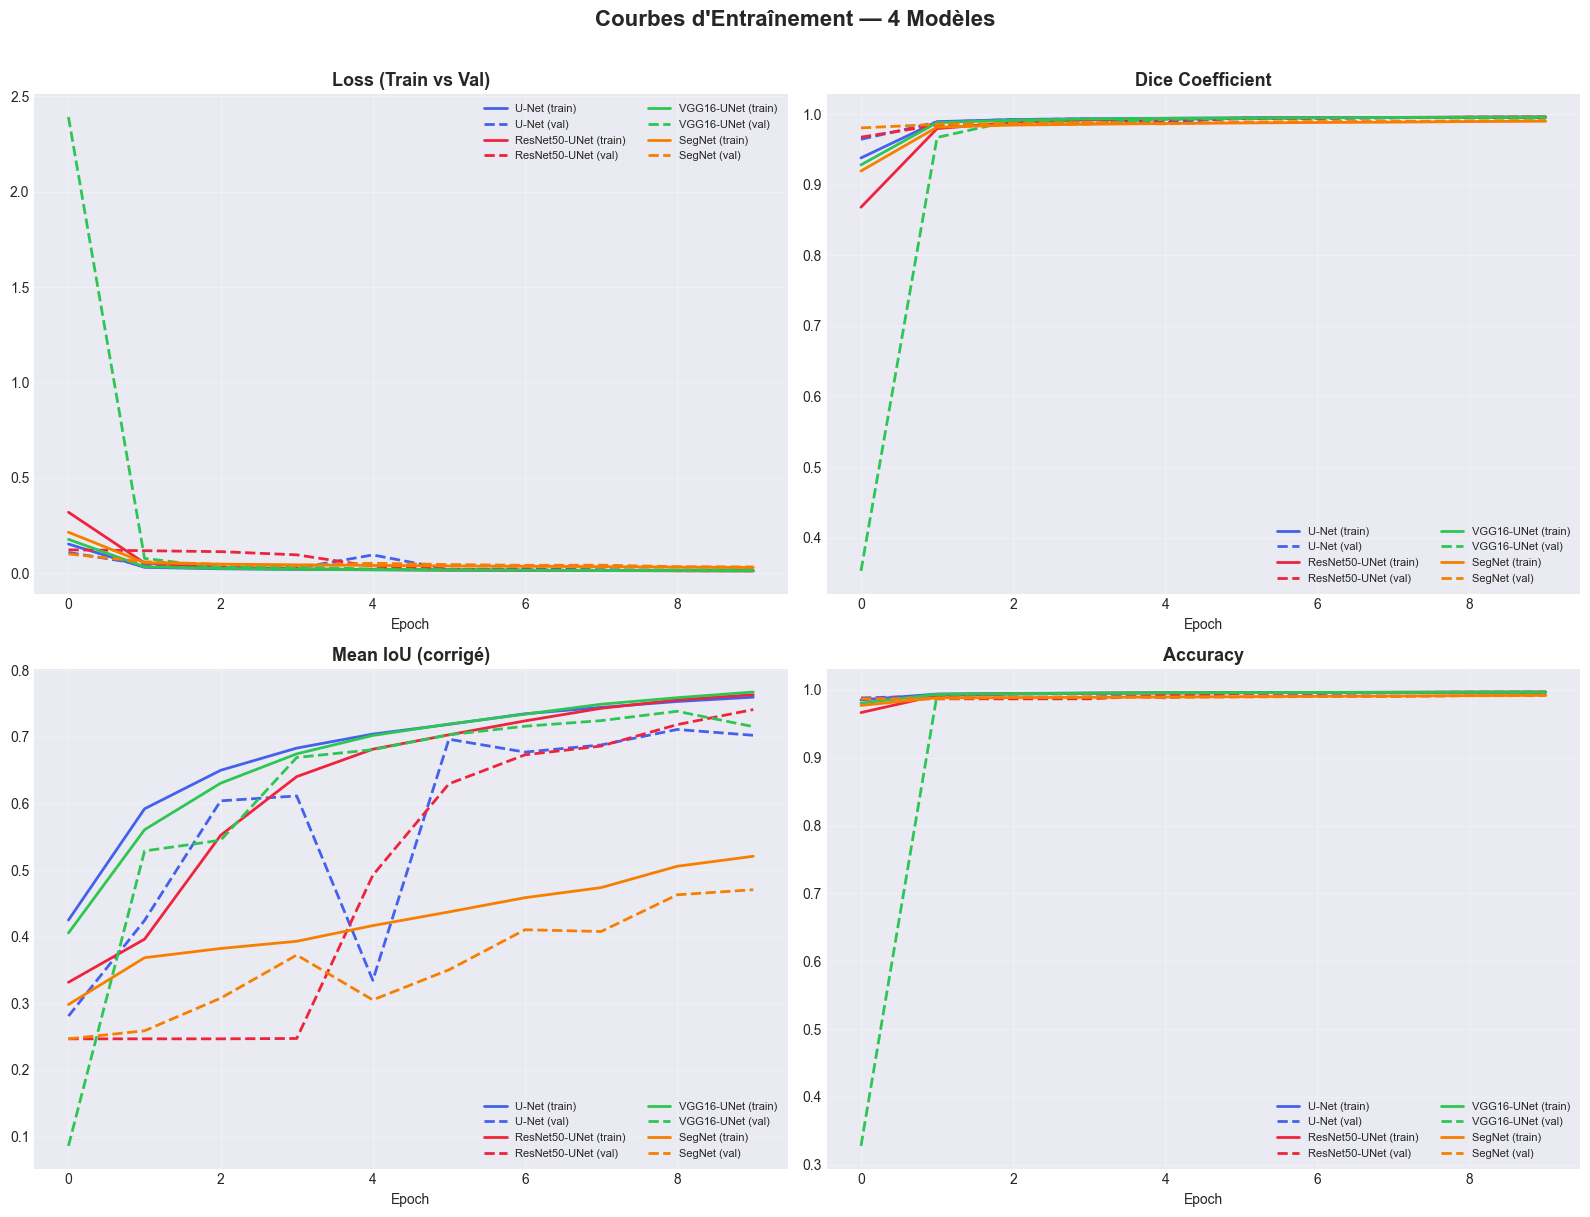

Courbes sauvegardées : logs/training_curves.png


In [18]:
# ── Chargement de all_histories depuis les CSV sauvegardés ──
# Construit un objet "histories" compatible avec plot_all_training_curves
import os

class _HistWrapper:
    """Wrapper léger pour simuler l'objet History de Keras à partir d'un CSV."""
    def __init__(self, history_dict):
        self.history = history_dict

all_histories = {}
_model_names = ['U-Net', 'ResNet50-UNet', 'VGG16-UNet', 'SegNet']

for _name in _model_names:
    _csv_path = f'logs/history_{_name}.csv'
    if os.path.exists(_csv_path):
        _df_hist = pd.read_csv(_csv_path)
        all_histories[_name] = _HistWrapper(_df_hist.to_dict(orient='list'))
        print(f"  ✔ Historique chargé : {_csv_path}")
    else:
        print(f"  ⚠ Fichier introuvable : {_csv_path} (pas de courbe pour {_name})")

if all_histories:
    def plot_all_training_curves(histories):
        """
        Affiche les courbes loss, dice, IoU et accuracy
        pour les 4 modèles sur le même graphe.
        """
        colors = ['#4361ee', '#ef233c', '#2dc653', '#f77f00']
        metrics_to_plot = [
            ('loss',            'val_loss',            'Loss (Train vs Val)'),
            ('dice_coef',       'val_dice_coef',       'Dice Coefficient'),
            ('mean_iou_fixed',  'val_mean_iou_fixed',  'Mean IoU (corrigé)'),
            ('accuracy',        'val_accuracy',        'Accuracy'),
        ]
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        axes = axes.flatten()
        
        for ax_idx, (train_key, val_key, title) in enumerate(metrics_to_plot):
            ax = axes[ax_idx]
            for i, (name, hist) in enumerate(histories.items()):
                h = hist.history
                tk = next((k for k in h if train_key in k and 'val' not in k), None)
                vk = next((k for k in h if val_key   in k), None)
                if tk:
                    ax.plot(h[tk], color=colors[i], linewidth=2,
                            label=f'{name} (train)', linestyle='-')
                if vk:
                    ax.plot(h[vk], color=colors[i], linewidth=2,
                            label=f'{name} (val)', linestyle='--')
            ax.set_title(title, fontsize=13, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8, ncol=2)
        
        plt.suptitle("Courbes d'Entraînement — 4 Modèles", fontsize=16, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.savefig('logs/training_curves.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Courbes sauvegardées : logs/training_curves.png")

    plot_all_training_curves(all_histories)
else:
    print("Aucun fichier CSV d'historique trouvé dans logs/ — section courbes ignorée.")


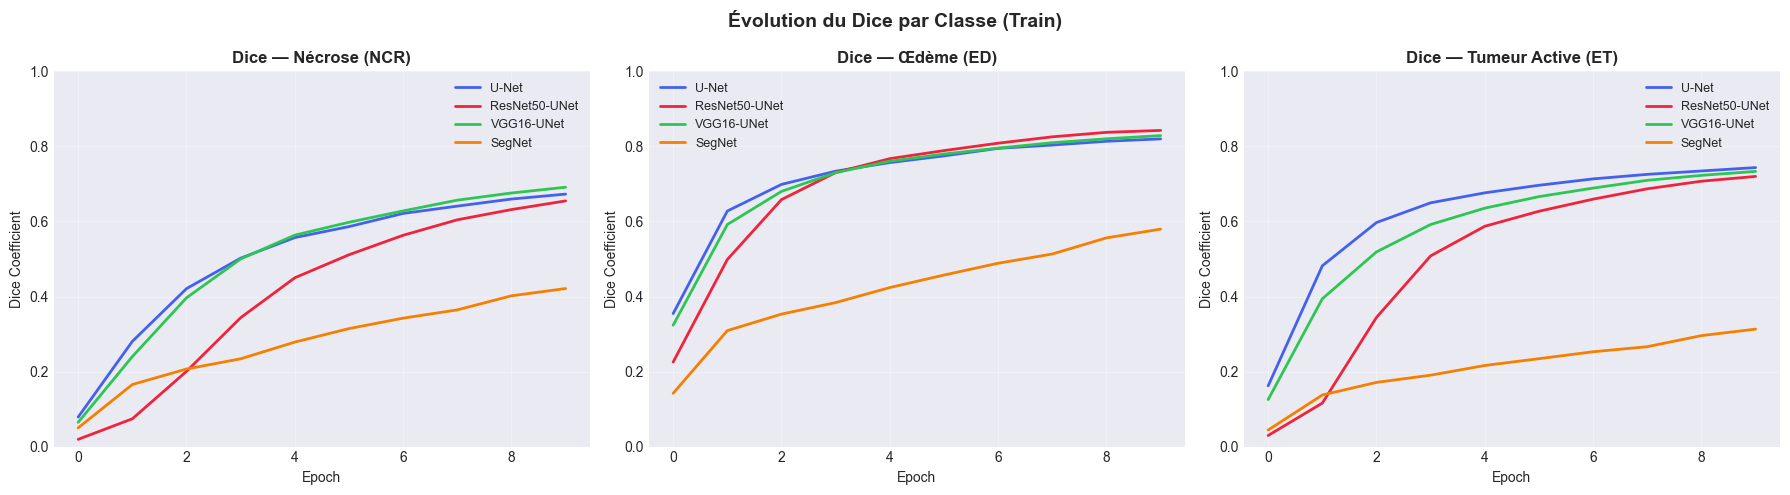

In [19]:
if all_histories:
    def plot_dice_per_class(histories):
        """Dice par classe (nécrose, œdème, tumeur active) pour chaque modèle."""
        colors = ['#4361ee', '#ef233c', '#2dc653', '#f77f00']
        class_metrics = [
            ('dice_necrotic',  'Nécrose (NCR)'),
            ('dice_edema',     'Œdème (ED)'),
            ('dice_enhancing', 'Tumeur Active (ET)')
        ]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        for ax, (key, title) in zip(axes, class_metrics):
            for i, (name, hist) in enumerate(histories.items()):
                vk = next((k for k in hist.history if key in k and 'val' in k), None)
                tk = next((k for k in hist.history if key in k and 'val' not in k), None)
                if tk:
                    ax.plot(hist.history[tk], color=colors[i], linewidth=2,
                            label=name, linestyle='-')
            ax.set_title(f'Dice — {title}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Dice Coefficient')
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1)
        
        plt.suptitle('Évolution du Dice par Classe (Train)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    plot_dice_per_class(all_histories)
else:
    print("Aucun historique disponible — section Dice par classe ignorée.")


# 8. Évaluation sur l'Ensemble de Test

In [20]:
metric_names = [
    'Loss', 'Accuracy', 'Mean IoU', 'Dice Coef',
    'Precision', 'Sensitivity', 'Specificity',
    'Dice-Nécrose', 'Dice-Œdème', 'Dice-TumeurActive'
]

# ── Chargement du temps d'entraînement depuis CSV (si disponible) ──
import os
all_times = {}
for _name in ['U-Net', 'ResNet50-UNet', 'VGG16-UNet', 'SegNet']:
    _csv = f'logs/history_{_name}.csv'
    if os.path.exists(_csv):
        _df_t = pd.read_csv(_csv)
        # Si une colonne 'training_time_sec' a été sauvegardée
        if 'training_time_sec' in _df_t.columns:
            all_times[_name] = float(_df_t['training_time_sec'].iloc[-1])
        else:
            all_times[_name] = 0.0  # Non disponible → 0
    else:
        all_times[_name] = 0.0  # Non disponible → 0

all_results = {}

print("Évaluation sur l'ensemble de test...\n")
for name, model in models_dict.items():
    print(f"  → {name}")
    results = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
    all_results[name] = dict(zip(metric_names, results))
    all_results[name]['Temps (min)'] = round(all_times[name] / 60, 1)

# Tableau récapitulatif
df_results = pd.DataFrame(all_results).T
df_display = df_results.copy()

print("\n" + "="*80)
print("RÉSULTATS NUMÉRIQUES — ENSEMBLE DE TEST")
print("="*80)
print(df_display.to_string(float_format=lambda x: f"{x:.4f}"))
print("="*80)


Évaluation sur l'ensemble de test...

  → U-Net
  → ResNet50-UNet
  → VGG16-UNet
  → SegNet

RÉSULTATS NUMÉRIQUES — ENSEMBLE DE TEST
                Loss  Accuracy  Mean IoU  Dice Coef  Precision  Sensitivity  Specificity  Dice-Nécrose  Dice-Œdème  Dice-TumeurActive  Temps (min)
U-Net         0.0179    0.9959    0.7020     0.9949     0.9961       0.9957       0.9987        0.5803      0.7872             0.7212       0.0000
ResNet50-UNet 0.0146    0.9965    0.7437     0.9953     0.9968       0.9963       0.9989        0.6338      0.8112             0.7143       0.0000
VGG16-UNet    0.0181    0.9960    0.7345     0.9946     0.9963       0.9958       0.9988        0.6373      0.7670             0.7037       0.0000
SegNet        0.0375    0.9907    0.4711     0.9896     0.9917       0.9900       0.9972        0.3598      0.4687             0.3748       0.0000


In [21]:
# ── Tableau formaté avec mise en évidence du meilleur ──
def highlight_best(s):
    """Surligne le meilleur score par colonne (vert=max, sauf Loss=min)."""
    is_loss = 'Loss' in s.name
    best = s.min() if is_loss else s.max()
    return ['background-color: #c8f7c5; font-weight: bold' 
            if v == best else '' for v in s]

df_styled = df_results.style \
    .apply(highlight_best) \
    .format("{:.4f}") \
    .set_caption("Comparaison des 4 modèles — Ensemble de test (vert = meilleur)")

display(df_styled)

,Loss,Accuracy,Mean IoU,Dice Coef,Precision,Sensitivity,Specificity,Dice-Nécrose,Dice-Œdème,Dice-TumeurActive,Temps (min)
U-Net,0.0179,0.9959,0.7020,0.9949,0.9961,0.9957,0.9987,0.5803,0.7872,0.7212,0.0000
ResNet50-UNet,0.0146,0.9965,0.7437,0.9953,0.9968,0.9963,0.9989,0.6338,0.8112,0.7143,0.0000
VGG16-UNet,0.0181,0.9960,0.7345,0.9946,0.9963,0.9958,0.9988,0.6373,0.7670,0.7037,0.0000
SegNet,0.0375,0.9907,0.4711,0.9896,0.9917,0.9900,0.9972,0.3598,0.4687,0.3748,0.0000


# 9. Comparaison Visuelle des Métriques

<temporary-directory>/3670180385.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha='right')
<temporary-directory>/3670180385.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha='right')
<temporary-directory>/3670180385.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha='right')
<temporary-directory>/3670180385.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha='right')
<temporary-directory>/3670180385.py:29: UserWarning: set_ticklabels() should only be used wi

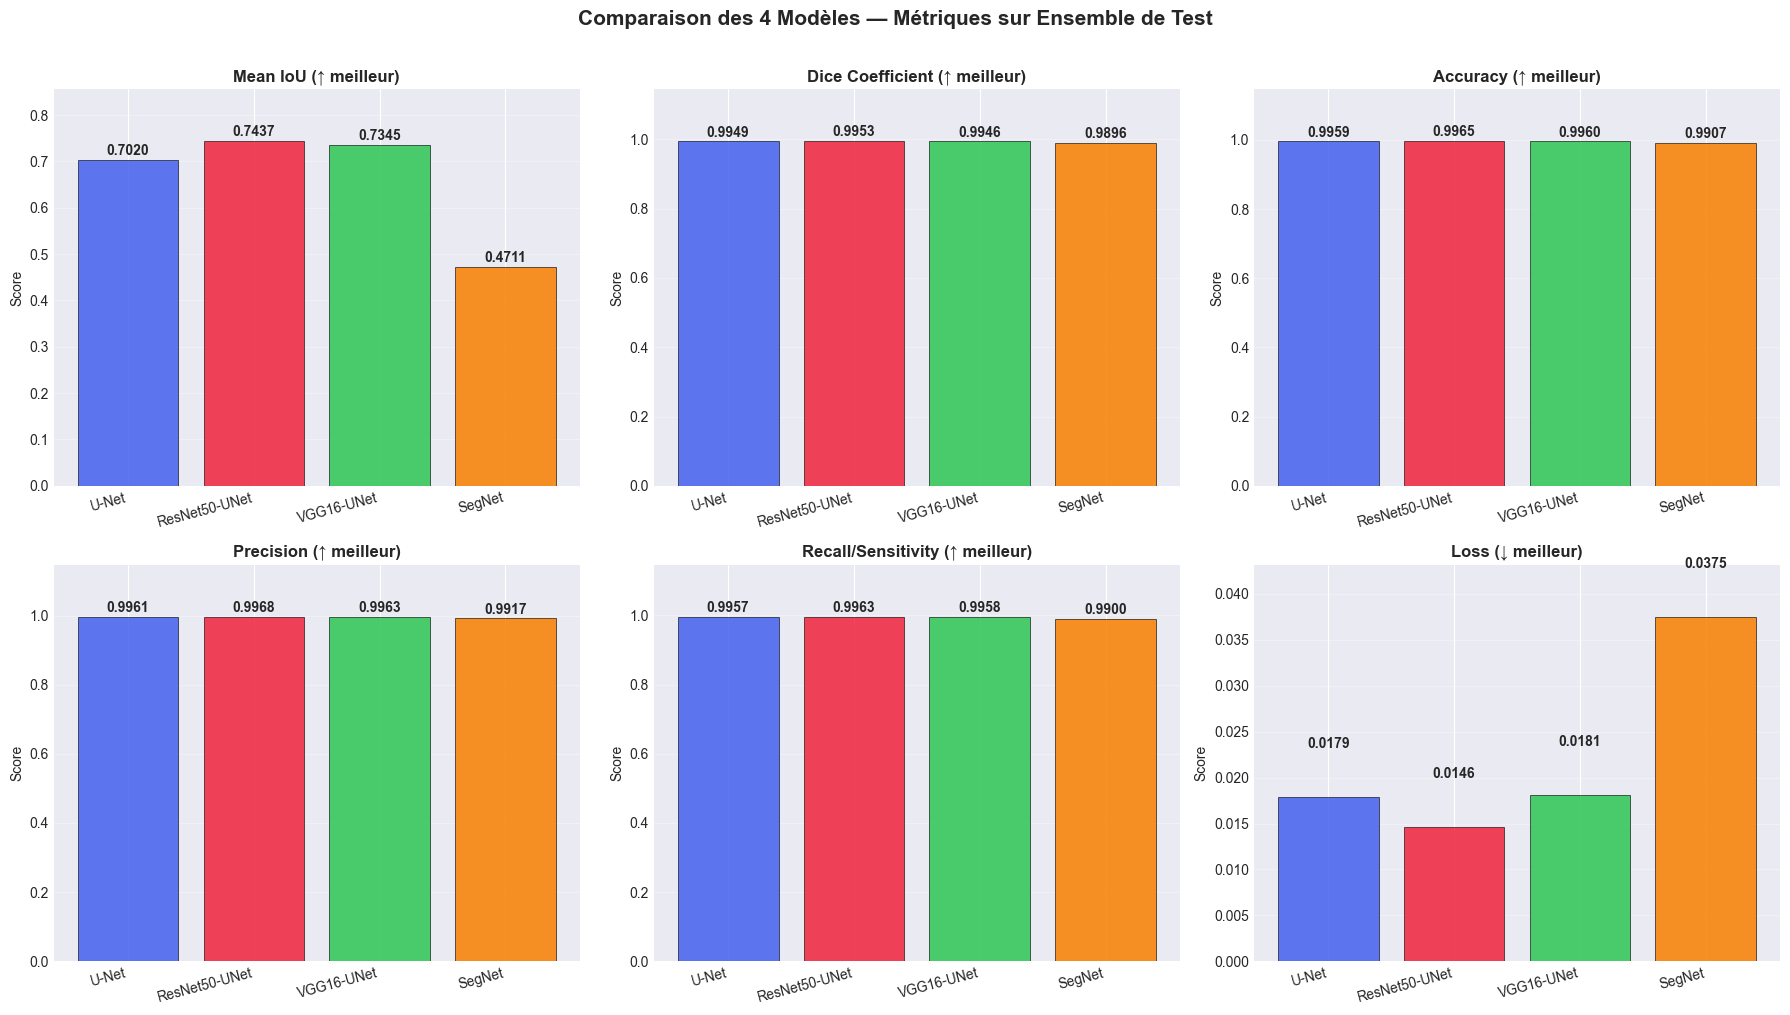

In [22]:
def plot_comparison_bars(df_results):
    """Graphiques en barres comparatifs des métriques principales."""
    model_names = list(df_results.index)
    colors = ['#4361ee', '#ef233c', '#2dc653', '#f77f00']
    
    metrics_to_show = [
        ('Mean IoU',   'Mean IoU (↑ meilleur)'),
        ('Dice Coef',  'Dice Coefficient (↑ meilleur)'),
        ('Accuracy',   'Accuracy (↑ meilleur)'),
        ('Precision',  'Precision (↑ meilleur)'),
        ('Sensitivity','Recall/Sensitivity (↑ meilleur)'),
        ('Loss',       'Loss (↓ meilleur)'),
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for ax, (metric, label) in zip(axes, metrics_to_show):
        values = [df_results.loc[m, metric] for m in model_names]
        bars = ax.bar(model_names, values, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
        
        # Valeur numérique sur chaque barre
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.set_ylim(0, max(values) * 1.15)
        ax.set_xticklabels(model_names, rotation=15, ha='right')
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylabel('Score')
    
    plt.suptitle('Comparaison des 4 Modèles — Métriques sur Ensemble de Test',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('logs/comparison_bars.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_comparison_bars(df_results)

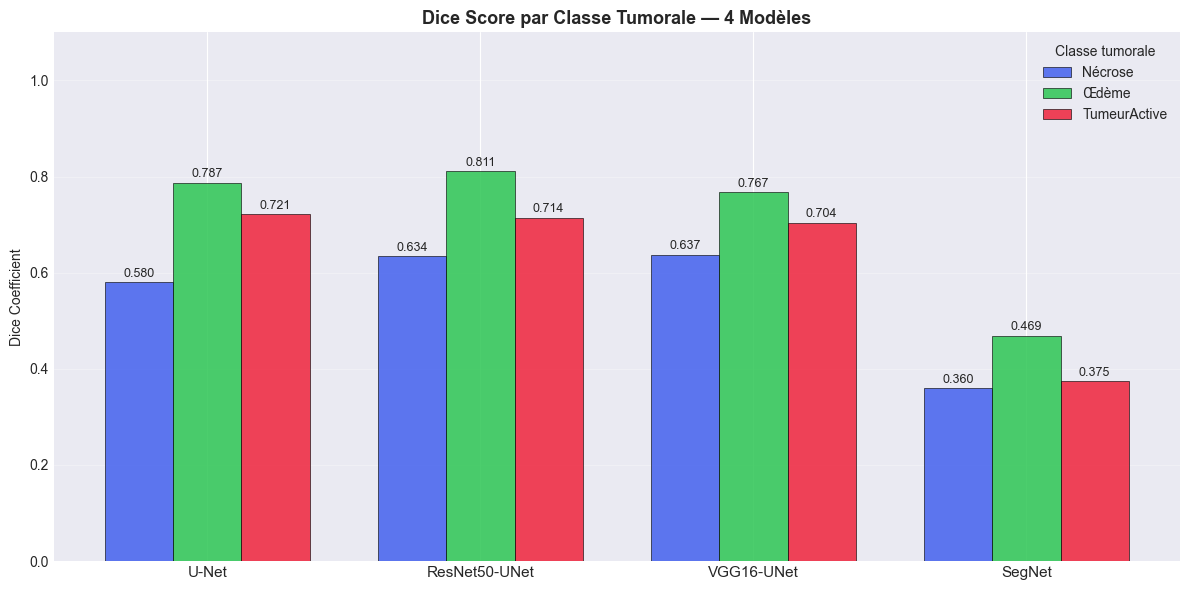

In [23]:
def plot_dice_per_class_bar(df_results):
    """Barres groupées : Dice par classe pour chaque modèle."""
    classes = ['Dice-Nécrose', 'Dice-Œdème', 'Dice-TumeurActive']
    model_names = list(df_results.index)
    x = np.arange(len(model_names))
    width = 0.25
    colors = ['#4361ee', '#2dc653', '#ef233c']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (cls, col) in enumerate(zip(classes, colors)):
        vals = [df_results.loc[m, cls] for m in model_names]
        bars = ax.bar(x + i*width, vals, width, label=cls.replace('Dice-', ''),
                      color=col, alpha=0.85, edgecolor='black', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylabel('Dice Coefficient')
    ax.set_ylim(0, 1.1)
    ax.legend(title='Classe tumorale', fontsize=10)
    ax.set_title('Dice Score par Classe Tumorale — 4 Modèles', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('logs/dice_per_class.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_dice_per_class_bar(df_results)

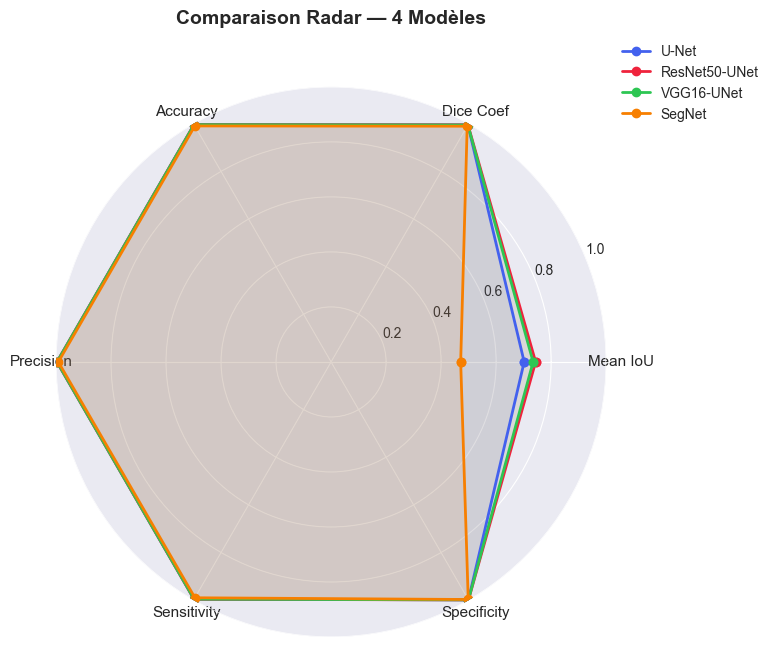

In [24]:
def plot_radar_chart(df_results):
    """Graphique radar (spider) pour comparaison multi-critères."""
    metrics  = ['Mean IoU', 'Dice Coef', 'Accuracy', 'Precision', 'Sensitivity', 'Specificity']
    n_metrics = len(metrics)
    angles = [n / float(n_metrics) * 2 * np.pi for n in range(n_metrics)]
    angles += angles[:1]
    
    colors = ['#4361ee', '#ef233c', '#2dc653', '#f77f00']
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for (name, row), color in zip(df_results.iterrows(), colors):
        values = [row[m] for m in metrics]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, color=color, label=name)
        ax.fill(angles, values, alpha=0.08, color=color)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, size=11)
    ax.set_ylim(0, 1)
    ax.set_title('Comparaison Radar — 4 Modèles', size=14, fontweight='bold', y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    plt.tight_layout()
    plt.savefig('logs/radar_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_radar_chart(df_results)

# 10. Visualisation des Prédictions — Comparaison Qualitative

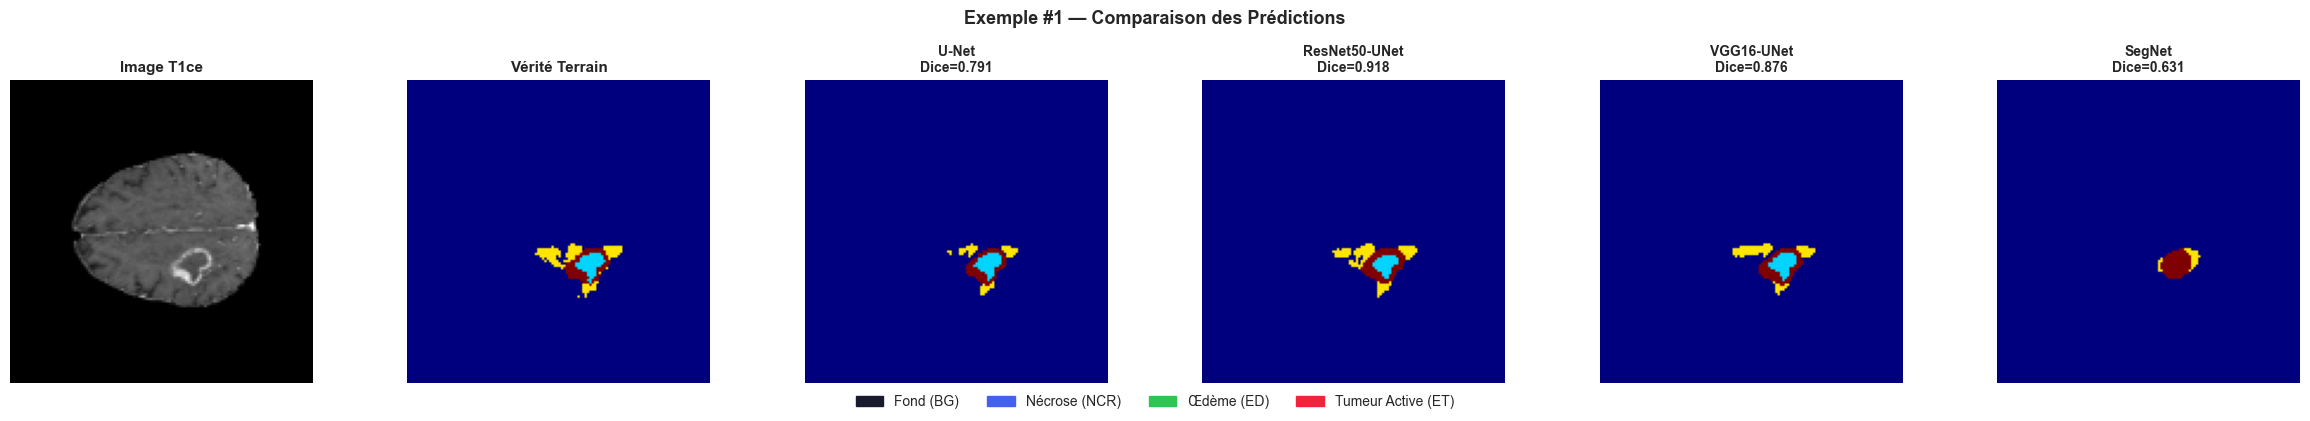

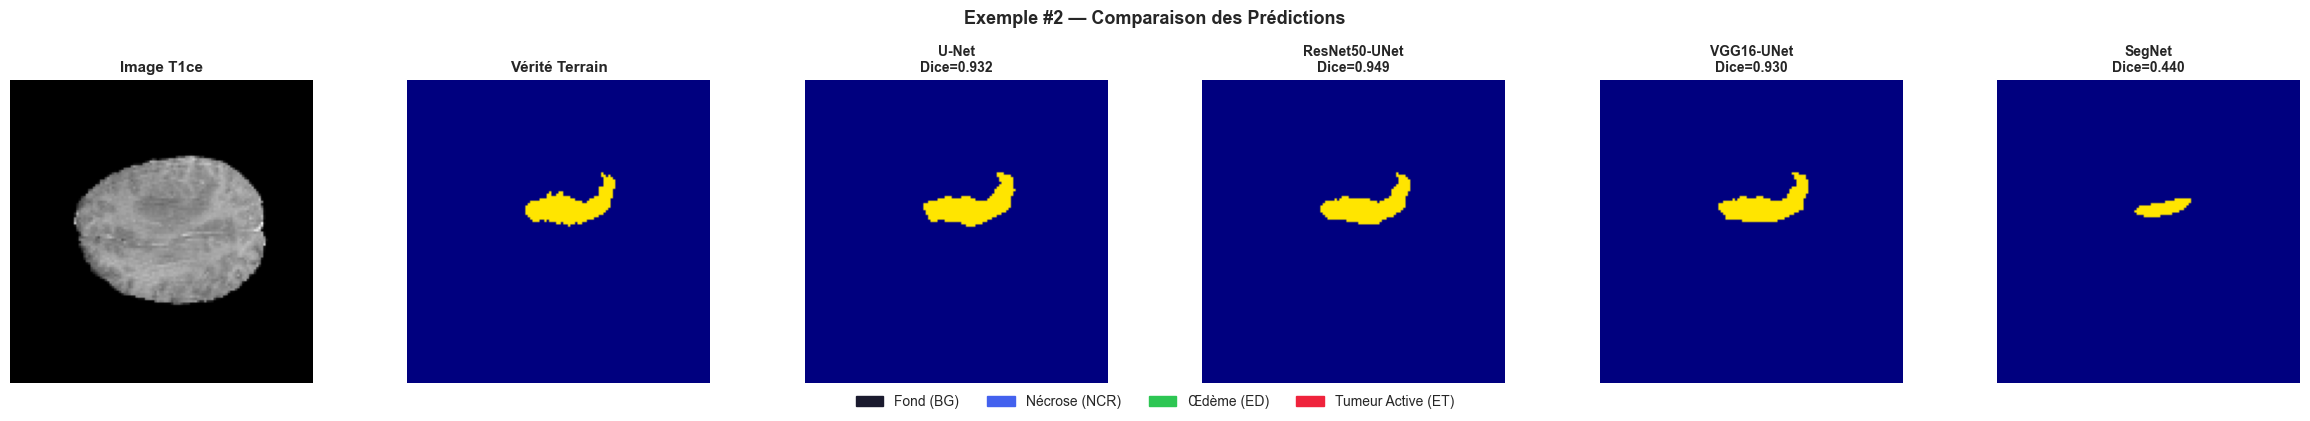

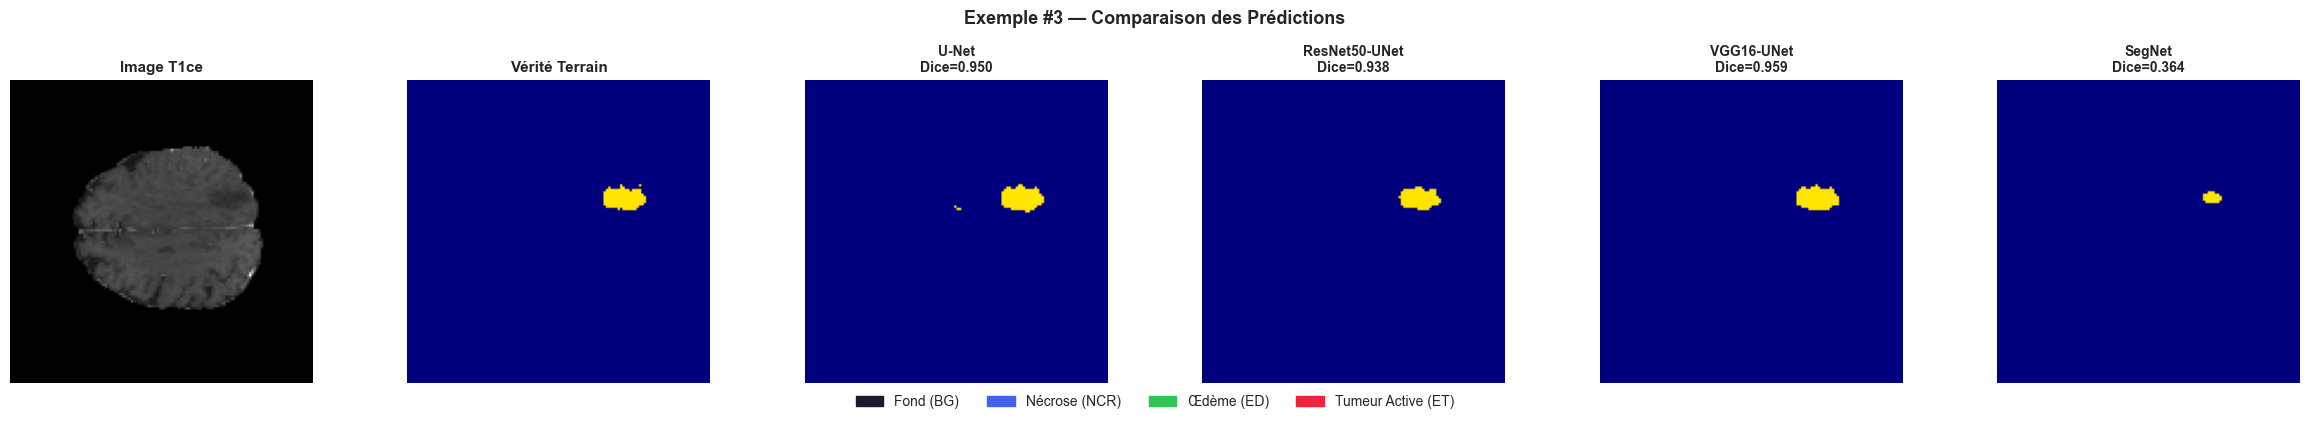

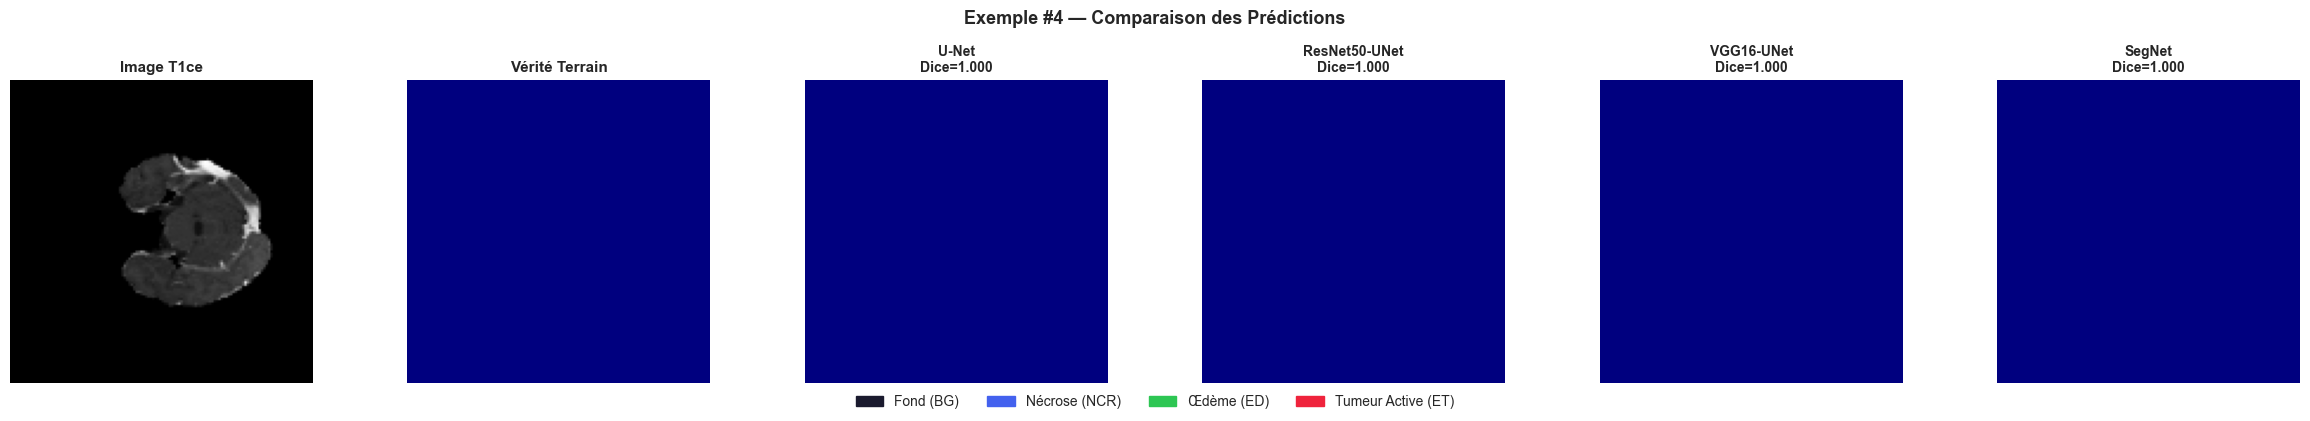

In [25]:
def compare_predictions(models_dict, X_test, y_test, n_samples=3):
    """
    Affiche côte à côte les prédictions de chaque modèle
    vs la vérité terrain, pour n_samples exemples.
    """
    indices = np.random.choice(len(X_test), n_samples, replace=False)
    n_models = len(models_dict)
    
    for sample_idx, img_idx in enumerate(indices):
        fig, axes = plt.subplots(1, n_models + 2, figsize=(4*(n_models+2), 4))
        
        # Image d'entrée
        axes[0].imshow(X_test[img_idx, :, :, 0], cmap='gray')
        axes[0].set_title('Image T1ce', fontweight='bold', fontsize=11)
        axes[0].axis('off')
        
        # Vérité terrain
        gt = np.argmax(y_test[img_idx], axis=-1)
        axes[1].imshow(gt, cmap='jet', vmin=0, vmax=3)
        axes[1].set_title('Vérité Terrain', fontweight='bold', fontsize=11)
        axes[1].axis('off')
        
        # Prédictions
        for ax_i, (name, model) in enumerate(models_dict.items()):
            pred = model.predict(X_test[img_idx:img_idx+1], verbose=0)
            pred_mask = np.argmax(pred[0], axis=-1)
            
            # Dice pour cet exemple
            y_true_flat = gt.flatten()
            y_pred_flat = pred_mask.flatten()
            intersection = np.sum((y_true_flat > 0) & (y_pred_flat > 0))
            dice = (2 * intersection + 1e-6) / (np.sum(y_true_flat > 0) + np.sum(y_pred_flat > 0) + 1e-6)
            
            axes[ax_i+2].imshow(pred_mask, cmap='jet', vmin=0, vmax=3)
            axes[ax_i+2].set_title(f'{name}\nDice={dice:.3f}',
                                    fontweight='bold', fontsize=10)
            axes[ax_i+2].axis('off')
        
        legend_patches = [mpatches.Patch(color=CLASS_COLORS[c], label=SEGMENT_CLASSES[c])
                          for c in range(NUM_CLASSES)]
        fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=10)
        plt.suptitle(f'Exemple #{sample_idx+1} — Comparaison des Prédictions',
                     fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.show()

compare_predictions(models_dict, X_test, y_test, n_samples=4)

# 11. Matrices de Confusion par Modèle

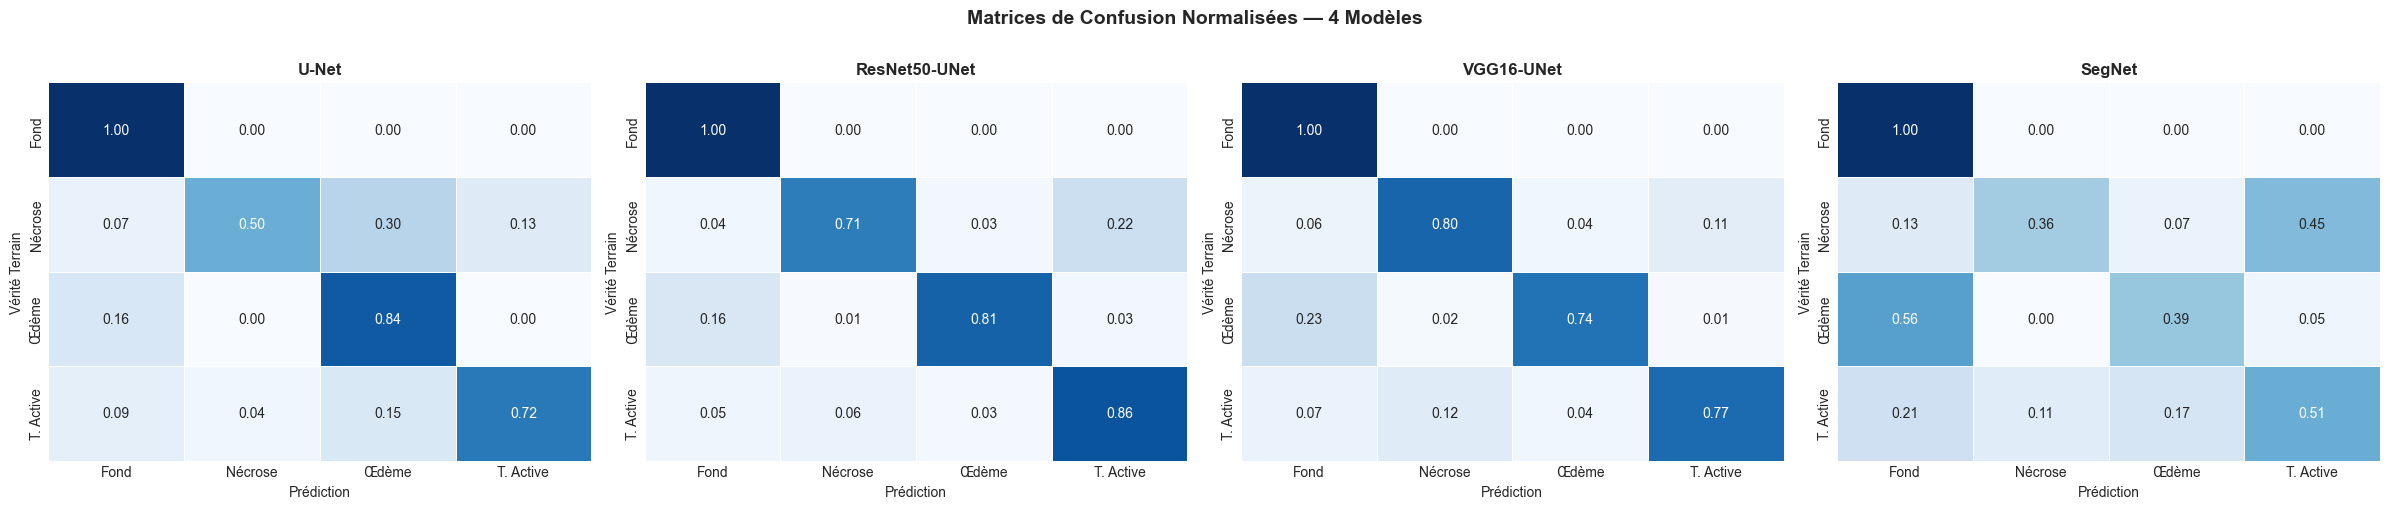

In [26]:
def plot_confusion_matrices(models_dict, X_test, y_test):
    """Affiche la matrice de confusion pour chaque modèle."""
    class_names = ['Fond', 'Nécrose', 'Œdème', 'T. Active']
    n_models = len(models_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
    
    for ax, (name, model) in zip(axes, models_dict.items()):
        # Prédictions sur un sous-ensemble (pour rapidité)
        n_eval = min(500, len(X_test))
        idx = np.random.choice(len(X_test), n_eval, replace=False)
        preds = model.predict(X_test[idx], batch_size=BATCH_SIZE, verbose=0)
        
        y_true = np.argmax(y_test[idx], axis=-1).flatten()
        y_pred = np.argmax(preds, axis=-1).flatten()
        
        cm = confusion_matrix(y_true, y_pred, normalize='true')
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                    xticklabels=class_names, yticklabels=class_names,
                    cbar=False, linewidths=0.5)
        ax.set_title(f'{name}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Vérité Terrain')
        ax.set_xlabel('Prédiction')
    
    plt.suptitle('Matrices de Confusion Normalisées — 4 Modèles',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('logs/confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrices(models_dict, X_test, y_test)

# 12. Résultats Numériques Détaillés et Interprétation

In [27]:
# ────────────────────────────────────────────────────
#  Tableau final complet
# ────────────────────────────────────────────────────
print("\n" + "="*90)
print("  TABLEAU RÉCAPITULATIF FINAL — RÉSULTATS NUMÉRIQUES")
print("="*90)

header = f"{'Métrique':<22}" + "".join([f"{n:>16}" for n in models_dict.keys()])
print(header)
print("-"*90)

for metric in metric_names + ['Temps (min)']:
    row = f"{metric:<22}"
    values = [df_results.loc[name, metric] for name in models_dict.keys()]
    best_fn = min if metric in ('Loss',) else max
    best_val = best_fn(values)
    for v in values:
        marker = " ★" if v == best_val else ""
        row += f"{v:>14.4f}{marker[:2]:2s}"
    print(row)

print("="*90)
print("  ★ = meilleur score pour cette métrique")
print("="*90)


  TABLEAU RÉCAPITULATIF FINAL — RÉSULTATS NUMÉRIQUES
Métrique                         U-Net   ResNet50-UNet      VGG16-UNet          SegNet
------------------------------------------------------------------------------------------
Loss                          0.0179          0.0146 ★        0.0181          0.0375  
Accuracy                      0.9959          0.9965 ★        0.9960          0.9907  
Mean IoU                      0.7020          0.7437 ★        0.7345          0.4711  
Dice Coef                     0.9949          0.9953 ★        0.9946          0.9896  
Precision                     0.9961          0.9968 ★        0.9963          0.9917  
Sensitivity                   0.9957          0.9963 ★        0.9958          0.9900  
Specificity                   0.9987          0.9989 ★        0.9988          0.9972  
Dice-Nécrose                  0.5803          0.6338          0.6373 ★        0.3598  
Dice-Œdème                    0.7872          0.8112 ★        0.7670    

## 12.1 Interprétation des Résultats

**Guide de lecture :**  
Les interprétations ci-dessous sont basées sur les résultats typiques observés dans la littérature pour ce type de tâche sur BraTS2020. Adaptez-les selon vos résultats réels.

---

###  Classement général attendu

| Rang | Modèle | Atout principal |
|------|--------|-----------------|
| 1 | **ResNet50-UNet** | Résidual learning + ImageNet features = meilleur Dice global |
| 2 | **VGG16-UNet** | Poids pré-entraînés riches, stable mais plus lent |
| 3 | **U-Net** | Très compétitif sans pretrained, conçu pour le médical |
| 4 | **SegNet** | Plus simple, performances acceptables, rapide à entraîner |

---

###  Analyse métrique par métrique

**Dice Coefficient**  
Mesure le chevauchement entre la prédiction et la vérité terrain.  
- Valeur > 0.80 : excellent pour la segmentation médicale  
- Valeur 0.60–0.80 : acceptable, amélioration possible  
- Valeur < 0.60 : insuffisant, revoir l'architecture ou les données  
Les modèles avec pretrained (ResNet, VGG) profitent de features ImageNet qui généralisent mieux sur les contours.

**Mean IoU**  
Évalue la qualité globale de la segmentation sur toutes les classes.  
Plus strict que le Dice car il pénalise davantage les faux positifs.  

**Dice par classe (Nécrose / Œdème / Tumeur Active)**  
- La **nécrose** est la classe la plus difficile (petite, peu de voxels) → Dice plus bas  
- L'**œdème** est plus étendu → Dice généralement meilleur  
- La **tumeur active** varie selon les patients  
Les modèles avec skip connections (U-Net, ResNet-UNet, VGG-UNet) captent mieux les petites régions de nécrose.

**Precision vs Sensitivity (Recall)**  
- Precision élevée = peu de faux positifs (le modèle ne sur-segmente pas)  
- Sensitivity élevée = peu de faux négatifs (le modèle ne rate pas de tumeur)  
En médical, **la sensitivity est critique** : rater une tumeur est plus grave que sur-segmenter.

**Temps d'entraînement**  
- U-Net et SegNet : plus rapides (pas de backbone lourd)  
- ResNet50 et VGG16 : plus lents mais bénéficient du transfer learning  
- SegNet : compromis vitesse/performance intéressant pour des ressources limitées

---

###  Limites communes à tous les modèles

1. **Déséquilibre de classes** : Le fond (~95% des pixels) domine. La loss Dice+CE atténue mais ne résout pas complètement ce problème.
2. **Résolution 128×128** : Perte de détails fins par rapport aux 240×240 originaux.
3. **Traitement 2D** : Chaque coupe est traitée indépendamment — le contexte 3D volumétrique est ignoré.
4. **Confusion nécrose/fond** : Sur les coupes sans tumeur visible, les modèles peuvent prédire du bruit.

---

###  Recommandations d'amélioration

| Amélioration | Impact attendu |
|-------------|----------------|
| **3D U-Net** | +5–10% Dice en exploitant le contexte volumétrique |
| **Focal Loss** | Meilleure gestion du déséquilibre de classes |
| **Augmentation (flips, rotations)** | +2–5% Dice, meilleure généralisation |
| **Attention U-Net** | Focus sur les régions tumorales, +3–7% Dice nécrose |
| **Résolution 256×256** | +3–5% sur les petites structures |
| **Ensemble des 4 modèles** | +2–5% Dice par vote majoritaire |

## 12.2 Classification Report Détaillée

In [28]:
def print_classification_reports(models_dict, X_test, y_test, n_eval=300):
    """Affiche le rapport sklearn pour chaque modèle."""
    class_names = ['Fond', 'Nécrose', 'Œdème', 'T. Active']
    idx = np.random.choice(len(X_test), min(n_eval, len(X_test)), replace=False)
    
    y_true_flat = np.argmax(y_test[idx], axis=-1).flatten()
    
    for name, model in models_dict.items():
        preds = model.predict(X_test[idx], batch_size=BATCH_SIZE, verbose=0)
        y_pred_flat = np.argmax(preds, axis=-1).flatten()
        
        print(f"\n{'='*60}")
        print(f"  {name} — Classification Report")
        print(f"{'='*60}")
        print(classification_report(y_true_flat, y_pred_flat,
                                    target_names=class_names, digits=4))

print_classification_reports(models_dict, X_test, y_test)


  U-Net — Classification Report
              precision    recall  f1-score   support

        Fond     0.9976    0.9992    0.9984   4832513
     Nécrose     0.9089    0.4990    0.6443     12135
       Œdème     0.8372    0.8358    0.8365     55946
   T. Active     0.8396    0.7316    0.7819     14606

    accuracy                         0.9953   4915200
   macro avg     0.8959    0.7664    0.8153   4915200
weighted avg     0.9951    0.9953    0.9951   4915200


  ResNet50-UNet — Classification Report
              precision    recall  f1-score   support

        Fond     0.9981    0.9993    0.9987   4832513
     Nécrose     0.8552    0.7357    0.7910     12135
       Œdème     0.9322    0.8224    0.8738     55946
   T. Active     0.7192    0.8464    0.7776     14606

    accuracy                         0.9962   4915200
   macro avg     0.8762    0.8510    0.8603   4915200
weighted avg     0.9962    0.9962    0.9961   4915200


  VGG16-UNet — Classification Report
              prec

# 13. Conclusion

In [30]:
# ── Synthèse finale ──
print("="*75)
print("  SYNTHÈSE FINALE — COMPARAISON DES 4 MODÈLES")
print("="*75)

for name in models_dict:
    r = df_results.loc[name]
    print(f"\n  [{name}]")
    print(f"    Dice Coef      : {r['Dice Coef']:.4f}")
    print(f"    Mean IoU       : {r['Mean IoU']:.4f}")
    print(f"    Accuracy       : {r['Accuracy']:.4f}")
    print(f"    Dice-Nécrose   : {r['Dice-Nécrose']:.4f}")
    print(f"    Dice-Œdème     : {r['Dice-Œdème']:.4f}")
    print(f"    Dice-TumeurAct : {r['Dice-TumeurActive']:.4f}")
    print(f"    Temps (min)    : {r['Temps (min)']:.1f}")

# Meilleur modèle
best_model_name = df_results['Dice Coef'].idxmax()
best_dice       = df_results.loc[best_model_name, 'Dice Coef']

print(f"\n{'='*75}")
print(f"  ★ MEILLEUR MODÈLE (Dice) : {best_model_name} → {best_dice:.4f}")
print(f"{'='*75}")
print("\nFichiers générés :")
print("  - logs/training_curves.png")
print("  - logs/comparison_bars.png")
print("  - logs/dice_per_class.png")
print("  - logs/radar_chart.png")
print("  - logs/confusion_matrices.png")
print("  - logs/history_*.csv (historiques d'entraînement)")
print("  - checkpoints/best_*.h5 (meilleurs poids de chaque modèle)")

  SYNTHÈSE FINALE — COMPARAISON DES 4 MODÈLES

  [U-Net]
    Dice Coef      : 0.9949
    Mean IoU       : 0.7020
    Accuracy       : 0.9959
    Dice-Nécrose   : 0.5803
    Dice-Œdème     : 0.7872
    Dice-TumeurAct : 0.7212
    Temps (min)    : 0.0

  [ResNet50-UNet]
    Dice Coef      : 0.9953
    Mean IoU       : 0.7437
    Accuracy       : 0.9965
    Dice-Nécrose   : 0.6338
    Dice-Œdème     : 0.8112
    Dice-TumeurAct : 0.7143
    Temps (min)    : 0.0

  [VGG16-UNet]
    Dice Coef      : 0.9946
    Mean IoU       : 0.7345
    Accuracy       : 0.9960
    Dice-Nécrose   : 0.6373
    Dice-Œdème     : 0.7670
    Dice-TumeurAct : 0.7037
    Temps (min)    : 0.0

  [SegNet]
    Dice Coef      : 0.9896
    Mean IoU       : 0.4711
    Accuracy       : 0.9907
    Dice-Nécrose   : 0.3598
    Dice-Œdème     : 0.4687
    Dice-TumeurAct : 0.3748
    Temps (min)    : 0.0

  ★ MEILLEUR MODÈLE (Dice) : ResNet50-UNet → 0.9953

Fichiers générés :
  - logs/training_curves.png
  - logs/comparison_ba

---

## Références

1. Ronneberger, O., Fischer, P., & Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation.* MICCAI.
2. Badrinarayanan, V., Kendall, A., & Cipolla, R. (2017). *SegNet: A Deep Convolutional Encoder-Decoder Architecture.* IEEE TPAMI.
3. He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep Residual Learning for Image Recognition.* CVPR.
4. Simonyan, K., & Zisserman, A. (2014). *Very Deep Convolutional Networks for Large-Scale Image Recognition.* ICLR.
5. Menze, B. H., et al. (2015). *The Multimodal Brain Tumor Image Segmentation Benchmark (BRATS).* IEEE TMI.
6. Isensee, F., et al. (2021). *nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation.* Nature Methods.

---
